# Hands-on Task 1: Autoencoder Representation Learning

1. Load Data

In [12]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="/Users/kenny/Research/notebook/research-preparation-federated-clustering/data",
    train=True,
    download=False,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="/Users/kenny/Research/notebook/research-preparation-federated-clustering/data",
    train=False,
    download=False,
    transform=transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,#randomly shuffle the data at every epoch
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,#do not shuffle the data for testing
)

2. Build AE

In [13]:
from torch import nn

class Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(),                 
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim),     
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid(),                 
            nn.Unflatten(1, (1, 28, 28)),  
        )

    def forward(self, x):
        z = self.encoder(x)
        reconstructed = self.decoder(z)
        return reconstructed


model = Autoencoder(latent_dim=16)

3. Train the AE to reconstruct the input

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.MSELoss()#损失函数
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)#优化器，learning rate = 0.001

epochs = 10

for epoch in range(epochs):
    model.train()
    train_loss = 0

    # 每次取出一批图片和对应标签
    for images, _ in train_loader:
        images = images.to(device)
        #清空上次的梯度
        optimizer.zero_grad()
        #前向传播，得到重建的图片
        reconstructed = model(images)
        #计算损失函数
        loss = criterion(reconstructed, images)
        #反向传播，计算梯度
        loss.backward()
        #更新参数
        optimizer.step()
        #累计训练损失
        train_loss += loss.item() * images.size(0)

    #计算平均训练损失
    average_loss = train_loss / len(train_loader.dataset)

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {average_loss:.4f}")

Epoch [1/10], Loss: 0.0687
Epoch [2/10], Loss: 0.0342
Epoch [3/10], Loss: 0.0267
Epoch [4/10], Loss: 0.0237
Epoch [5/10], Loss: 0.0214
Epoch [6/10], Loss: 0.0200
Epoch [7/10], Loss: 0.0186
Epoch [8/10], Loss: 0.0173
Epoch [9/10], Loss: 0.0163
Epoch [10/10], Loss: 0.0155


4. Display original samples and reconstructed samples（10 samples）

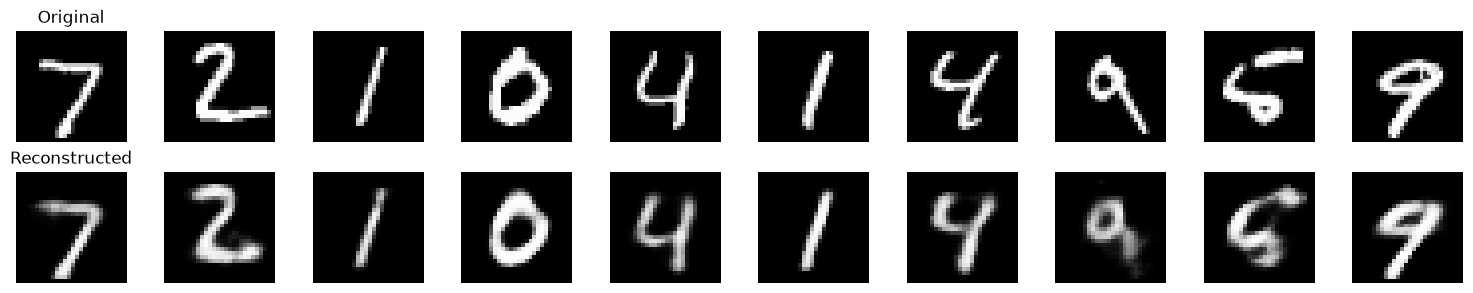

In [15]:
import matplotlib.pyplot as plt

model.eval()

images, _ = next(iter(test_loader))
images = images[:10]

with torch.no_grad():
    reconstructed = model(images.to(device)).cpu()

fig, axes = plt.subplots(2, 10, figsize=(15, 3))

for i in range(10):
    
    axes[0, i].imshow(
        images[i, 0].cpu().numpy(),
        cmap="gray", vmin=0, vmax=1
    )

    axes[1, i].imshow(
        reconstructed[i, 0].numpy(),
        cmap="gray", vmin=0, vmax=1
    )

    axes[0, i].axis("off")
    axes[1, i].axis("off")

axes[0, 0].set_title("Original")
axes[1, 0].set_title("Reconstructed")

plt.tight_layout()
plt.show()

5. Extract the latent representations

In [16]:
# 分别保存每个批次的特征和真实标签
latent_batches = []
label_batches = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        # 这里只调用编码器，不需要解码器
        # [batch_size, 1, 28, 28] → [batch_size, 16]
        z = model.encoder(images)

        # 移到 CPU，保存当前批次的结果
        latent_batches.append(z.cpu())

        # 同时保存对应标签，保证特征与标签顺序一致
        # 标签只用于最后评价，不参与特征提取或聚类
        label_batches.append(labels.cpu())

# 沿第 0 维拼接，把多个批次合成一个完整数组
Z = torch.cat(latent_batches, dim=0).numpy()
y_true = torch.cat(label_batches, dim=0).numpy()

6. Apply K-means to the latent representations and Calculate ARI and NMI using labels only for final evaluation.

In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# MNIST 有 10 个数字类别，这里预先设置聚成 10 簇
kmeans = KMeans(n_clusters=10, n_init=10, random_state=47)

# 只使用 16 维特征进行聚类，没有传入真实标签
# 返回每张图片所属的簇，形状为 (10000,)
cluster_labels = kmeans.fit_predict(Z)

# 聚类结束后，才使用真实标签评价结果
ari = adjusted_rand_score(y_true, cluster_labels)
nmi = normalized_mutual_info_score(y_true, cluster_labels)

print(f"ARI: {ari:.4f}")
print(f"NMI: {nmi:.4f}")

ARI: 0.3351
NMI: 0.4675


above is 16 dimension, follow let's try 8 and 32 dimension

In [19]:
# 创建新的 8 维 AE，并为它创建优化器
model_8 = Autoencoder(latent_dim=8).to(device)
optimizer_8 = torch.optim.Adam(model_8.parameters(), lr=1e-3)

# 训练
for epoch in range(epochs):
    model_8.train()
    train_loss = 0.0

    for images, _ in train_loader:
        images = images.to(device)

        optimizer_8.zero_grad()
        reconstructed = model_8(images)
        loss = criterion(reconstructed, images)
        loss.backward()
        optimizer_8.step()

        train_loss += loss.item() * images.size(0)

    average_loss = train_loss / len(train_loader.dataset)
    print(f"AE-8, Epoch {epoch + 1}/{epochs}, Loss: {average_loss:.4f}")

# 提取测试图片的 8 维特征
latent_batches_8 = []
label_batches_8 = []

model_8.eval()
with torch.no_grad():
    for images, labels in test_loader:
        z = model_8.encoder(images.to(device))  # [batch_size, 8]
        latent_batches_8.append(z.cpu())
        label_batches_8.append(labels.cpu())

Z_8 = torch.cat(latent_batches_8, dim=0).numpy()
y_true_8 = torch.cat(label_batches_8, dim=0).numpy()

# 只使用特征进行聚类
kmeans_8 = KMeans(n_clusters=10, n_init=10, random_state=47)
cluster_labels_8 = kmeans_8.fit_predict(Z_8)

# 真实标签只用于最终评价
ari_8 = adjusted_rand_score(y_true_8, cluster_labels_8)
nmi_8 = normalized_mutual_info_score(y_true_8, cluster_labels_8)

print(f"AE-8: ARI={ari_8:.4f}, NMI={nmi_8:.4f}")

AE-8, Epoch 1/10, Loss: 0.0691
AE-8, Epoch 2/10, Loss: 0.0367
AE-8, Epoch 3/10, Loss: 0.0285
AE-8, Epoch 4/10, Loss: 0.0255
AE-8, Epoch 5/10, Loss: 0.0238
AE-8, Epoch 6/10, Loss: 0.0228
AE-8, Epoch 7/10, Loss: 0.0220
AE-8, Epoch 8/10, Loss: 0.0214
AE-8, Epoch 9/10, Loss: 0.0210
AE-8, Epoch 10/10, Loss: 0.0205
AE-8: ARI=0.4339, NMI=0.5373


In [ ]:
# 创建新的 32 维 AE，并为它创建优化器
model_32 = Autoencoder(latent_dim=32).to(device)
optimizer_32 = torch.optim.Adam(model_32.parameters(), lr=1e-3)

# 训练
for epoch in range(epochs):
    model_32.train()
    train_loss = 0.0

    for images, _ in train_loader:
        images = images.to(device)

        optimizer_32.zero_grad()
        reconstructed = model_32(images)
        loss = criterion(reconstructed, images)
        loss.backward()
        optimizer_32.step()

        train_loss += loss.item() * images.size(0)

    average_loss = train_loss / len(train_loader.dataset)
    print(f"AE-32, Epoch {epoch + 1}/{epochs}, Loss: {average_loss:.4f}")

# 提取测试图片的 32 维特征
latent_batches_32 = []
label_batches_32 = []

model_32.eval()
with torch.no_grad():
    for images, labels in test_loader:
        z = model_32.encoder(images.to(device))  # [batch_size, 32]
        latent_batches_32.append(z.cpu())
        label_batches_32.append(labels.cpu())

Z_32 = torch.cat(latent_batches_32, dim=0).numpy()
y_true_32 = torch.cat(label_batches_32, dim=0).numpy()

# 只使用特征进行聚类
kmeans_32 = KMeans(n_clusters=10, n_init=10, random_state=47)
cluster_labels_32 = kmeans_32.fit_predict(Z_32)

# 真实标签只用于最终评价
ari_32 = adjusted_rand_score(y_true_32, cluster_labels_32)
nmi_32 = normalized_mutual_info_score(y_true_32, cluster_labels_32)

print("Z_32 shape:", Z_32.shape)  # (10000, 32)
print(f"AE-32: ARI={ari_32:.4f}, NMI={nmi_32:.4f}")